Saving Advertising.csv to Advertising (2).csv
First 5 Rows of Dataset
   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9

Dataset Shape:
(200, 5)

Column Names:
Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

Missing Values:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

===== MODEL PERFORMANCE =====
Mean Absolute Error : 1.46
Mean Squared Error  : 3.17
R2 Score            : 0.8994


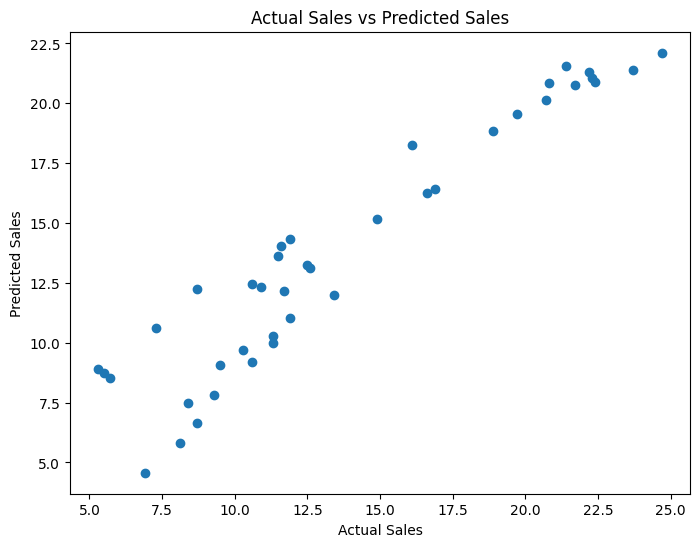


Advertising Impact on Sales
     Feature  Coefficient
1      Radio     0.189195
0         TV     0.044730
2  Newspaper     0.002761

Predicted Sales for Sample Advertisement Budget:
20.61


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [2]:
# ==========================================
# SALES PREDICTION USING PYTHON
# CodeAlpha Data Science Internship
# ==========================================

# STEP 1 : Import Required Libraries

import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# STEP 2 : Upload Dataset
# ==========================================

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

sales_data = pd.read_csv(file_name)

# ==========================================
# STEP 3 : Display Dataset Information
# ==========================================

print("First 5 Rows of Dataset")
print(sales_data.head())

print("\nDataset Shape:")
print(sales_data.shape)

print("\nColumn Names:")
print(sales_data.columns)

# ==========================================
# STEP 4 : Check Missing Values
# ==========================================

print("\nMissing Values:")
print(sales_data.isnull().sum())

# Remove missing values if any
sales_data.dropna(inplace=True)

# ==========================================
# STEP 5 : Select Features and Target
# ==========================================

X = sales_data[['TV', 'Radio', 'Newspaper']]

y = sales_data['Sales']

# ==========================================
# STEP 6 : Split Dataset
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ==========================================
# STEP 7 : Train Model
# ==========================================

model = LinearRegression()

model.fit(X_train, y_train)

# ==========================================
# STEP 8 : Make Predictions
# ==========================================

predictions = model.predict(X_test)

# ==========================================
# STEP 9 : Evaluate Model
# ==========================================

print("\n===== MODEL PERFORMANCE =====")

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error :", round(mae, 2))
print("Mean Squared Error  :", round(mse, 2))
print("R2 Score            :", round(r2, 4))

# ==========================================
# STEP 10 : Actual vs Predicted Graph
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual Sales vs Predicted Sales")

plt.show()

# ==========================================
# STEP 11 : Feature Importance
# ==========================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\nAdvertising Impact on Sales")
print(importance.sort_values(
    by='Coefficient',
    ascending=False
))

# ==========================================
# STEP 12 : Predict Sales for New Data
# ==========================================

sample_data = [[230.1, 37.8, 69.2]]

predicted_sales = model.predict(sample_data)

print("\nPredicted Sales for Sample Advertisement Budget:")

print(round(predicted_sales[0], 2))